In [109]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
# --- CONFIGURACIÓN ---
# Ruta a la carpeta donde están los CSV
ruta_carpeta = r"C:\Users\david\Downloads\reneuroborosdescargardatos"   # ← cámbiala, por ejemplo: "C:/Users/D/Documents/bienestar_datos"

# Columnas de interés (ajusta nombres exactamente a tus CSV)
columnas = [
    '\ufeff"ID"', "Data",
    "Son", "Exercici físic", "Dieta", "Dispositius mòbils", "Relacions socials",
    "Satisfacció", "Calma", "Poder"
]


In [111]:
# --- LECTURA DE TODOS LOS CSV ---
dfs = []  # lista donde guardaremos cada DataFrame limpio

for archivo in os.listdir(ruta_carpeta):
    if archivo.endswith(".csv"):
        ruta = os.path.join(ruta_carpeta, archivo)
        try:
            # Leer CSV (detecta separador automáticamente)
            df = pd.read_csv(ruta, encoding="utf-8", sep=None, engine="python")
            
            # Filtrar columnas de interés (solo si existen)
            columnas_presentes = [col for col in columnas if col in df.columns]
            df = df[columnas_presentes]

            # Eliminar filas con datos faltantes
            df = df.dropna(subset=columnas_presentes)
                        
            # Añadir al listado de DataFrames
            dfs.append(df)
            print(f"✅ Cargado {archivo}: {df.shape[0]} filas válidas")

        except Exception as e:
            print(f"⚠️ Error al leer {archivo}: {e}")


# --- UNIFICAR TODOS LOS CSV ---
if dfs:
    df_total = pd.concat(dfs, ignore_index=True)
    df_total = df_total.rename(columns={'\ufeff"ID"': 'ID'})
    df_total = df_total.rename(columns={'Calma': 'Exitació'})
    print(f"\n📊 DataFrame combinado: {df_total.shape[0]} filas, {df_total.shape[1]} columnas")
else:
    df_total = pd.DataFrame(columns=columnas)
    print("⚠️ No se cargó ningún archivo CSV válido.")

✅ Cargado classroom-660313e93365e948487826c7-data-2025-09-08.csv: 24 filas válidas
✅ Cargado classroom-66042c413365e948487828cb-data-2025-09-08.csv: 23 filas válidas
✅ Cargado classroom-66053bb43365e94848782b0a-data-2025-09-08.csv: 259 filas válidas
✅ Cargado classroom-661658927ddbe1c2e6cd6206-data-2025-09-08.csv: 218 filas válidas
✅ Cargado classroom-661e78767ddbe1c2e6cd6a1c-data-2025-09-08.csv: 94 filas válidas
✅ Cargado classroom-661f96157ddbe1c2e6cd6bca-data-2025-09-08.csv: 102 filas válidas
✅ Cargado classroom-661fdb5d7ddbe1c2e6cd6cd4-data-2025-09-08.csv: 681 filas válidas
✅ Cargado classroom-661fdc667ddbe1c2e6cd6cff-data-2025-09-08.csv: 1109 filas válidas
✅ Cargado classroom-66dabaef97690661a55b7f4f-data-2025-09-08.csv: 67 filas válidas
✅ Cargado classroom-66db23ed97690661a55b80ba-data-2025-09-08.csv: 479 filas válidas
✅ Cargado classroom-66db287097690661a55b80ee-data-2025-09-08.csv: 342 filas válidas
✅ Cargado classroom-66e31b60b3275893657df36b-data-2025-09-08.csv: 271 filas vál

In [112]:
df_total["Data"] = pd.to_datetime(df_total["Data"], errors="coerce", utc=True).dt.tz_convert(None).dt.normalize()

# Ordena por sujeto y fecha (buena práctica)
df_total = df_total.sort_values(["ID", "Data"]).copy()

# Día de intervención = días calendario desde el primer registro del sujeto + 1
primer_dia = df_total.groupby("ID")["Data"].transform("min")
df_total["dia_intervencion"] = (df_total["Data"] - primer_dia).dt.days + 1



# --- Filtro: mantener solo días 1..90 ---
n_total = len(df_total)
mascara_valida = df_total["dia_intervencion"].between(1, 90, inclusive="both")

n_fuera = int((~mascara_valida).sum())
pct_fuera = (n_fuera / n_total * 100) if n_total > 0 else 0.0

print(f"Registros totales: {n_total}")
print(f"Registros fuera de 1..90 días: {n_fuera}  ({pct_fuera:.1f}%)")

# Aplicar filtro
df_total = df_total[mascara_valida].copy()
print(f"Registros restantes tras el filtro: {len(df_total)}")




df_total.head()


Registros totales: 5684
Registros fuera de 1..90 días: 236  (4.2%)
Registros restantes tras el filtro: 5448


,ID,Data,Son,Exercici físic,Dieta,Dispositius mòbils,Relacions socials,Satisfacció,Exitació,Poder,dia_intervencion
0,660313e93365e948487826c4,2024-03-27,1.00,0.33,1.0,1.00,0.33,8.0,3.0,7.0,1
1,660313e93365e948487826c4,2024-03-28,1.00,0.66,1.0,0.66,1.00,3.0,3.0,3.0,2
2,660313e93365e948487826c4,2024-04-02,0.00,0.00,0.0,0.66,0.66,8.0,5.0,6.0,7
3,660313e93365e948487826c4,2024-04-07,0.66,0.66,0.0,0.66,0.33,8.0,3.0,7.0,12
4,660313e93365e948487826c4,2024-04-09,0.00,0.00,0.0,0.66,0.00,5.0,5.0,5.0,14


count    414.000000
mean      13.159420
std       11.198785
min        1.000000
25%        5.000000
50%       10.000000
75%       18.750000
max       69.000000
Name: n_registros, dtype: float64


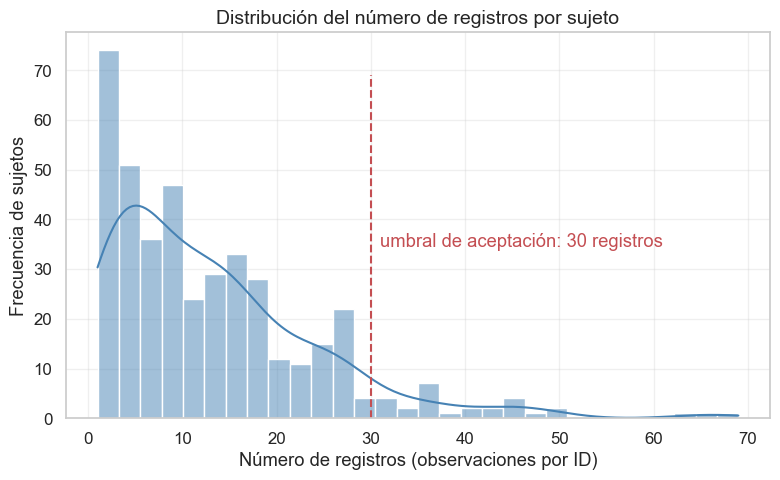

In [113]:
# Contar cuántas filas hay por ID
conteo = df_total["ID"].value_counts().sort_index()
conteo_df = conteo.reset_index()
conteo_df.columns = ["ID", "n_registros"]

# Mostrar estadísticas rápidas
print(conteo_df["n_registros"].describe())

# Gráfico de distribución
plt.figure(figsize=(8, 5))
sns.histplot(conteo_df["n_registros"], bins=30, kde=True, color="steelblue")
plt.title("Distribución del número de registros por sujeto", fontsize=14)
plt.xlabel("Número de registros (observaciones por ID)")
plt.ylabel("Frecuencia de sujetos")
umbral = 30
plt.plot([umbral,umbral], [0, conteo_df["n_registros"].max()], color='r', linestyle='--')
plt.text(x=umbral+1, y= conteo_df["n_registros"].max()/2, s=f'umbral de aceptación: {umbral} registros', color='r')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show(block=False)

In [114]:
# --- 3. Filtrar sujetos con al menos 20 registros ---
ids_validos = conteo_df.loc[conteo_df["n_registros"] >= umbral, "ID"]

df_filtrado = df_total[df_total["ID"].isin(ids_validos)].copy()

print(f"✅ Sujetos retenidos: {len(ids_validos)} de {conteo_df.shape[0]}")
print(f"📊 Filas finales: {df_filtrado.shape[0]} (umbral ≥ {umbral} registros)")

✅ Sujetos retenidos: 31 de 414
📊 Filas finales: 1269 (umbral ≥ 30 registros)


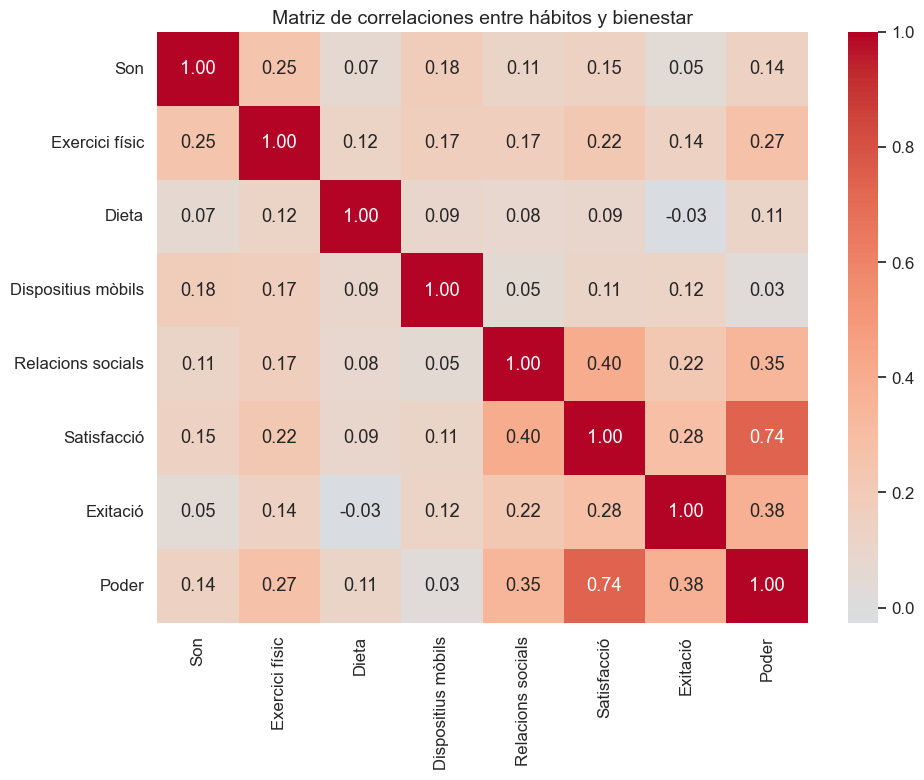

In [115]:
# --- 1. Correlaciones entre todas las variables ---
plt.figure(figsize=(10, 8))
corr = df_filtrado[["Son", "Exercici físic", "Dieta", "Dispositius mòbils", "Relacions socials",
    "Satisfacció", "Exitació", "Poder"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlaciones entre hábitos y bienestar", fontsize=14)
plt.tight_layout()
plt.show()

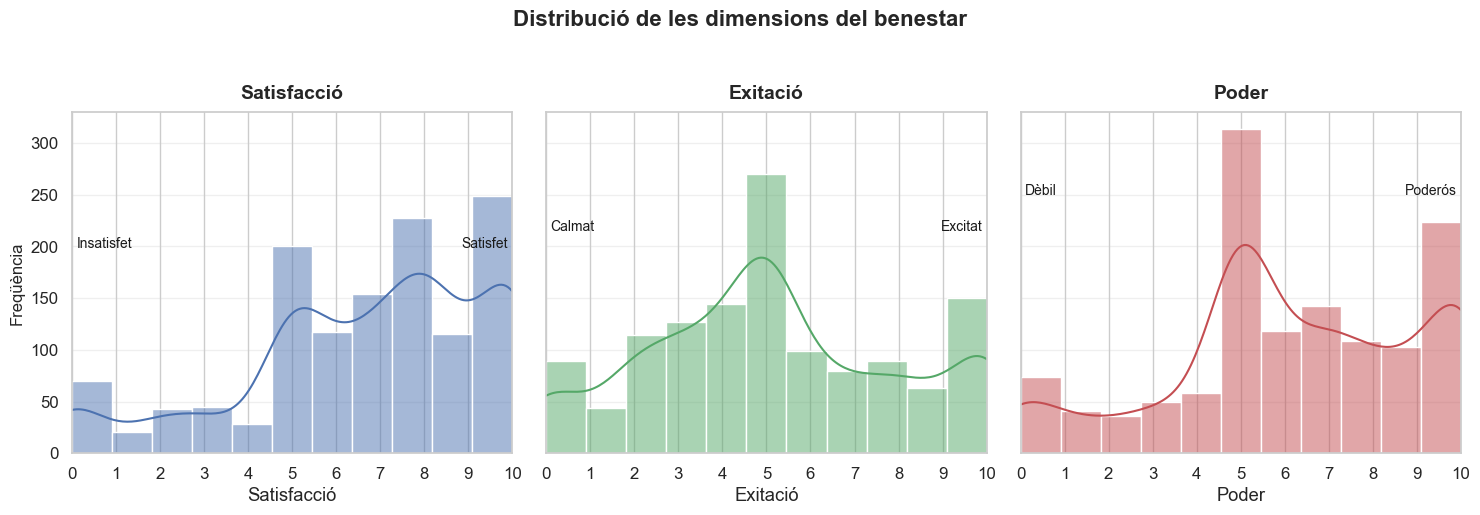

In [116]:
# Variables de bienestar (usa los nombres exactos de tus columnas)
variables = ["Satisfacció", "Exitació", "Poder"]
titulos = ["Satisfacció", "Exitació", "Poder"]
colores = ["#4C72B0", "#55A868", "#C44E52"]
etiquetas = [
    ("Insatisfet", "Satisfet"),
    ("Calmat", "Excitat"),
    ("Dèbil", "Poderós")
]

# Crear figura con 3 subplots en la misma fila
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, var in enumerate(variables):
    sns.histplot(df_filtrado[var], bins=11, kde=True, color=colores[i], ax=axes[i])
    axes[i].set_title(titulos[i], fontsize=14, weight="bold", pad=10)
    axes[i].set_xlim(0, 10)
    axes[i].set_xticks(range(0, 11))
    axes[i].grid(axis="y", alpha=0.3)
    
    # Etiquetas semánticas en extremos del eje X
    axes[i].text(0.1, axes[i].get_ylim()[1]*0.75, etiquetas[i][0],
                 ha="left", va="bottom", fontsize=10, color="k")
    axes[i].text(9.9, axes[i].get_ylim()[1]*0.75, etiquetas[i][1],
                 ha="right", va="bottom", fontsize=10, color="k")

    if i == 0:
        axes[i].set_ylabel("Freqüència", fontsize=12)
    else:
        axes[i].set_ylabel("")

# Título global
fig.suptitle("Distribució de les dimensions del benestar", fontsize=16, weight="bold", y=1.03)
plt.tight_layout()
plt.show()


In [117]:
## Modelos

In [118]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd

df = df_filtrado.copy()

In [119]:
#GLM
# Lista de predictores
df.columns = df.columns.str.replace(" ", "_").str.replace("ò", "o").str.replace("í", "i").str.replace("ó", "o").str.lower()

predictoras = ['son', 'exercici_fisic', 'dieta', 'dispositius_mobils',
       'relacions_socials']

# 1. Modelo para cada variable de bienestar
resultados = {}

for y in ['satisfaccio', 'exitacio', 'poder']:
    formula = f"{y} ~ {' + '.join(predictoras)}"
    model = smf.glm(formula=formula, data=df,
                    family=sm.families.Gaussian(sm.families.links.identity()))
    res = model.fit()
    resultados[y] = res

    print("\n" + "="*70)
    print(f"📈 Modelo para {y.upper()}")
    print(res.summary())
    print("="*70)


📈 Modelo para SATISFACCIO
                 Generalized Linear Model Regression Results                  
Dep. Variable:            satisfaccio   No. Observations:                 1269
Model:                            GLM   Df Residuals:                     1263
Model Family:                Gaussian   Df Model:                            5
Link Function:               identity   Scale:                          6.3377
Method:                          IRLS   Log-Likelihood:                -2969.2
Date:                Thu, 09 Oct 2025   Deviance:                       8004.6
Time:                        17:31:45   Pearson chi2:                 8.00e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2146
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept

C:\Users\david\anaconda3\envs\python3.10\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
C:\Users\david\anaconda3\envs\python3.10\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
C:\Users\david\anaconda3\envs\python3.10\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [120]:
# --- configuración ---
predictoras = ['son','exercici_fisic','dieta','dispositius_mobils','relacions_socials']
outcomes = ['satisfaccio','exitacio','poder']

# 1) ajustar modelos mixtos y guardar resultados
resultados_mixtos = {}
for y in outcomes:
    formula = f"{y} ~ {' + '.join(predictoras)}"
    #formula = f"{y} ~ 1 + {' + '.join(predictoras)}"
    print("\n" + "="*70)
    print(f"📈 Modelo mixto para: {y.upper()}")
    
    modelo = smf.mixedlm(formula, data=df, groups=df['id'])
    res = modelo.fit(reml=False)
    
    resultados_mixtos[y] = res
    print(res.summary())
    print("="*70)

# 2) construir tabla de coeficientes (filas=hábitos, columnas=outcomes)
coef_data = pd.DataFrame({'habito': predictoras})
for y, res in resultados_mixtos.items():
    # efectos fijos (omitimos el Intercept)
    coef_data[y] = [res.fe_params.get(p, np.nan) for p in predictoras]

# (opcional) nombres bonitos
nombres_habitos = {
    'son': 'Son',
    'exercici_fisic': 'Exercici físic',
    'dieta': 'Dieta',
    'dispositius_mobils': 'Dispositius mòbils',
    'relacions_socials': 'Relacions socials'
}
coef_data['label'] = coef_data['habito'].map(nombres_habitos).fillna(coef_data['habito'])





📈 Modelo mixto para: SATISFACCIO
           Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: satisfaccio
No. Observations:   1269    Method:             ML         
No. Groups:         31      Scale:              4.2854     
Min. group size:    30      Log-Likelihood:     -2771.4623 
Max. group size:    69      Converged:          Yes        
Mean group size:    40.9                                   
-----------------------------------------------------------
                   Coef. Std.Err.   z   P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept          3.887    0.416 9.347 0.000  3.072  4.703
son                0.260    0.188 1.383 0.167 -0.108  0.628
exercici_fisic     0.792    0.235 3.367 0.001  0.331  1.252
dieta              0.504    0.199 2.533 0.011  0.114  0.895
dispositius_mobils 0.439    0.231 1.905 0.057 -0.013  0.891
relacions_socials  1.878    0.221 8.492 0.000  1.445  2.312
Group Var        

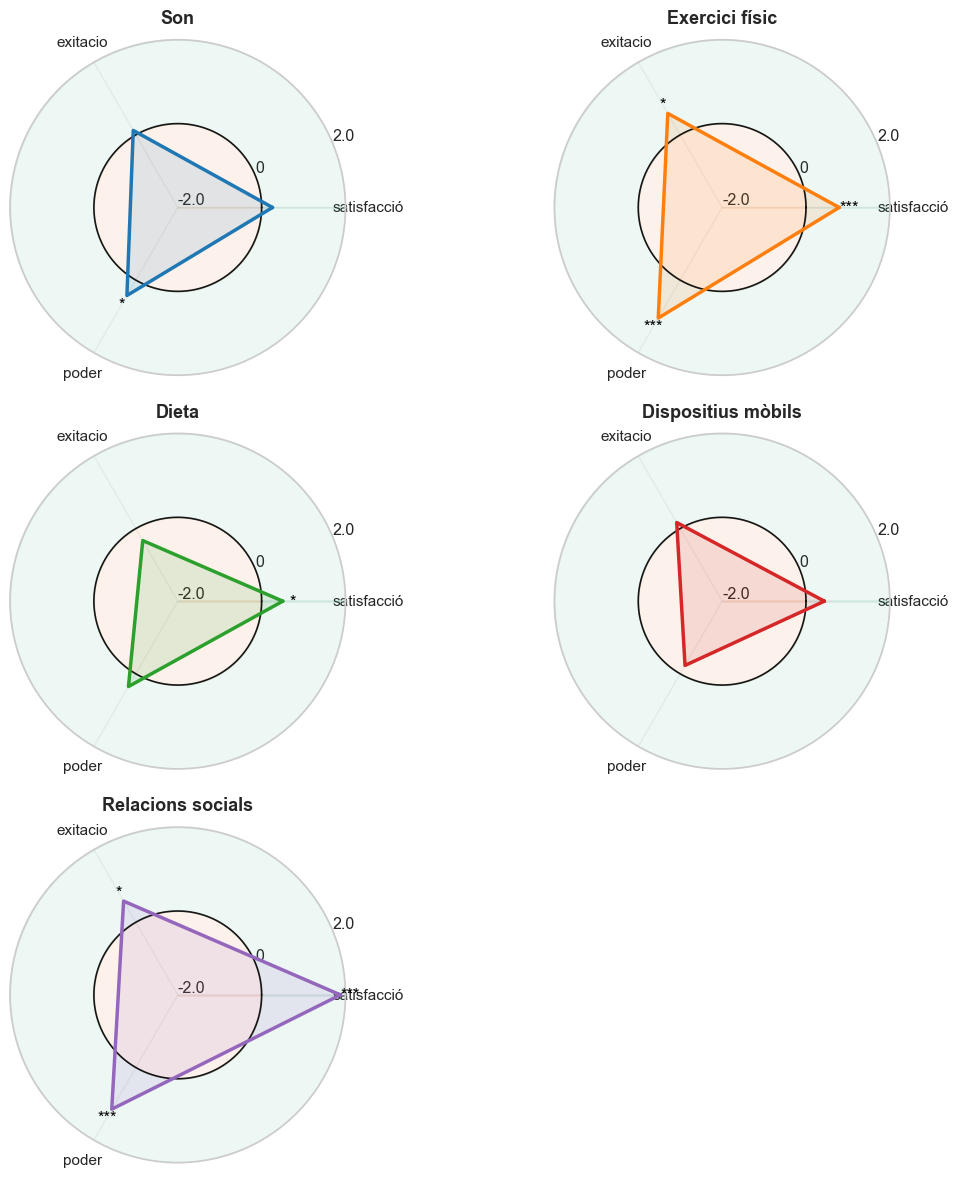

In [121]:
# --- Configuración de etiquetas ---
predictoras = ['son','exercici_fisic','dieta','dispositius_mobils','relacions_socials']
outcomes = ['satisfaccio','exitacio','poder']
et_out = ['satisfacció','exitacio','poder']
et_pred = {
    'son':'Son',
    'exercici_fisic':'Exercici físic',
    'dieta':'Dieta',
    'dispositius_mobils':'Dispositius mòbils',
    'relacions_socials':'Relacions socials'
}

# --- Extraer coeficientes y p-valores de efectos fijos ---
coef_df = pd.DataFrame(index=predictoras, columns=outcomes, dtype=float)
pval_df = pd.DataFrame(index=predictoras, columns=outcomes, dtype=float)

for y in outcomes:
    res = resultados_mixtos[y]
    for p in predictoras:
        coef_df.loc[p, y] = res.fe_params.get(p, np.nan)
        pval_df.loc[p, y] = res.pvalues.get(p, np.nan)

# --- Parámetros del radar ---
N = len(outcomes)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # cerrar polígono

# Escala radial común (simétrica) para todos los subplots
rad_max = float(np.nanmax(np.abs(coef_df.values)))
rad_lim = max(0.5, np.ceil(rad_max*2)/2)  # redondeo a múltiplos de 0.5
R = 2*rad_lim  # radio total tras remapeo ([-rad_lim, rad_lim] -> [0, 2*rad_lim])

def map_r(vals):
    """Remapea valores centrados en 0 a [0, 2*rad_lim] para dibujar fondo +/-."""
    return np.array(vals) + rad_lim

def estrellas(p):
    if pd.isna(p): return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# --- Plot ---
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, axes = plt.subplots(3, 2, figsize=(12, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

colors = plt.cm.tab10.colors

for i, pred in enumerate(predictoras):
    ax = axes[i]
    # Fondo positivo/negativo
    theta = np.linspace(0, 2*np.pi, 361)
    ax.fill_between(theta, rad_lim, R, color="#1b9e77", alpha=0.08)  # >0
    ax.fill_between(theta, 0,      rad_lim, color="#d95f02", alpha=0.08)  # <0
    ax.plot(theta, np.full_like(theta, rad_lim), color="black", lw=1.2, alpha=0.9)  # línea de cero

    # Ejes
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(et_out, fontsize=11)
    ax.set_ylim(0, R)
    ax.set_yticks([0, rad_lim, R])
    ax.set_yticklabels([f"{-rad_lim:.1f}", "0", f"{rad_lim:.1f}"])
    ax.grid(alpha=0.25)
    ax.set_title(et_pred.get(pred, pred), fontsize=13, weight="bold", pad=12)

    # Polígono del regresor (sus 3 coeficientes)
    vals = coef_df.loc[pred, outcomes].tolist()
    vals += vals[:1]
    r = map_r(vals)
    ax.plot(angles, r, color=colors[i % len(colors)], lw=2.5)
    ax.fill(angles, r, color=colors[i % len(colors)], alpha=0.12)

    # Asteriscos de significación en las puntas
    for j, y in enumerate(outcomes):
        p = pval_df.loc[pred, y]
        stars = estrellas(p)
        if stars:
            # Colocamos un poco más allá de la punta
            ax.text(angles[j], map_r([coef_df.loc[pred, y]])[0] + 0.06*R,
                    stars, ha="center", va="center", fontsize=12, color="black")

# Ocultar el 6º subplot vacío
if len(predictoras) < len(axes):
    axes[-1].axis("off")

plt.tight_layout()
plt.show()


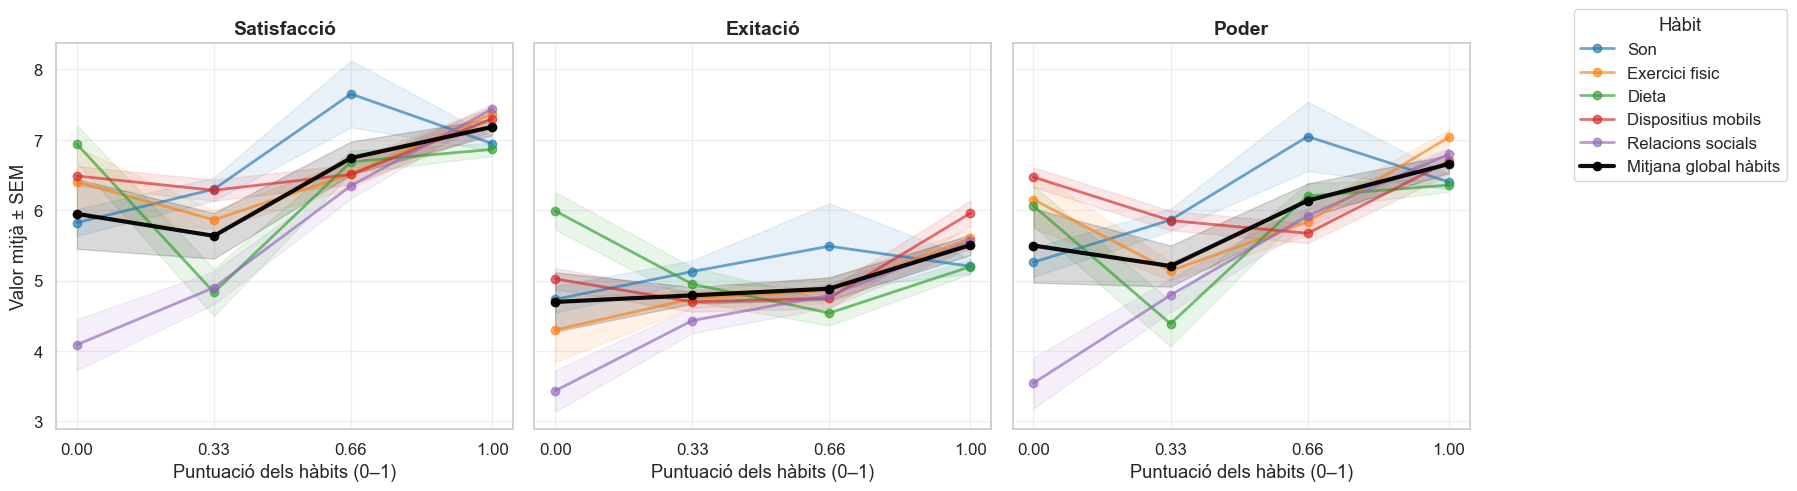

In [122]:
# --- Variables de interés ---
predictoras = ['son','exercici_fisic','dieta','dispositius_mobils','relacions_socials']
outcomes = ['satisfaccio','exitacio','poder']
et_out = ['Satisfacció', 'Exitació', 'Poder']

# --- Preparar el DataFrame en formato largo ---
df_long = df.melt(
    id_vars=predictoras,
    value_vars=outcomes,
    var_name='variable_bienestar',
    value_name='valor_bienestar'
)



sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
palette = sns.color_palette("tab10", len(predictoras))

for ax, yvar, titulo in zip(axes, outcomes, et_out):
    # --- líneas de cada hábito (más transparentes) ---
    for habito, color in zip(predictoras, palette):
        stats_table = (
            df.groupby(habito)[yvar]
              .agg(['mean','count','std'])
              .assign(sem=lambda x: x['std'] / np.sqrt(x['count']))
              .reset_index()
        )
        ax.plot(
            stats_table[habito], stats_table['mean'],
            marker='o', color=color, linewidth=2,
            label=habito.replace("_"," ").capitalize(), alpha=0.65
        )
        ax.fill_between(
            stats_table[habito],
            stats_table['mean'] - stats_table['sem'],
            stats_table['mean'] + stats_table['sem'],
            color=color, alpha=0.10
        )

    # --- línea negra: media entre hábitos por nivel + SEM entre hábitos ---
    niveles = [0, 0.33, 0.66, 1]
    medias_globales, sems_globales = [], []

    for nivel in niveles:
        # medias por hábito en ese nivel (puede faltar alguno)
        means_hab = []
        for habito in predictoras:
            vals = df.loc[np.isclose(df[habito], nivel, atol=0.01), yvar]
            if not vals.empty:
                means_hab.append(vals.mean())

        if len(means_hab) >= 2:
            m = float(np.nanmean(means_hab))
            sem = float(np.nanstd(means_hab, ddof=1) / np.sqrt(len(means_hab)))
        elif len(means_hab) == 1:
            m = float(means_hab[0])
            sem = np.nan
        else:
            m, sem = np.nan, np.nan

        medias_globales.append(m)
        sems_globales.append(sem)

    medias_globales = np.array(medias_globales, dtype=float)
    sems_globales = np.array(sems_globales, dtype=float)

    ax.plot(
        niveles, medias_globales,
        color='black', linewidth=3, marker='o', markersize=6,
        label='Mitjana global hàbits', alpha=0.95
    )

    # banda ±1 SEM de la media entre hábitos (donde haya datos)
    mask = ~np.isnan(medias_globales) & ~np.isnan(sems_globales)
    if mask.any():
        ax.fill_between(
            np.array(niveles)[mask],
            (medias_globales - sems_globales)[mask],
            (medias_globales + sems_globales)[mask],
            color='black', alpha=0.15
        )

    # estética
    ax.set_title(titulo, fontsize=14, weight="bold")
    ax.set_xlabel("Puntuació dels hàbits (0–1)")
    ax.set_ylabel("Valor mitjà ± SEM" if ax == axes[0] else "")
    ax.set_xticks([0, 0.33, 0.66, 1])
    ax.grid(alpha=0.3)


# Leyenda común
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title="Hàbit", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [123]:
##
import statsmodels.formula.api as smf

habitos = ['son','exercici_fisic','dieta','dispositius_mobils','relacions_socials']
resultados_dia = {}

for h in habitos:
    print("\n" + "="*70)
    print(f"📈 Modelo de cambio temporal para: {h.upper()}")
    
    formula = f"{h} ~ dia_intervencion"
    modelo = smf.mixedlm(formula, data=df, groups=df["id"])
    
    res = modelo.fit(reml=False, method="nm", maxiter=1000, disp=False)
    resultados_dia[h] = res
    print(res.summary())



📈 Modelo de cambio temporal para: SON
          Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  son      
No. Observations:  1269     Method:              ML       
No. Groups:        31       Scale:               0.0973   
Min. group size:   30       Log-Likelihood:      -371.7312
Max. group size:   69       Converged:           Yes      
Mean group size:   40.9                                   
----------------------------------------------------------
                 Coef. Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        0.703    0.046 15.268 0.000  0.613  0.793
dia_intervencion 0.000    0.000  0.527 0.598 -0.001  0.001
Group Var        0.058    0.050                           


📈 Modelo de cambio temporal para: EXERCICI_FISIC
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: exercici_fisic
No. Observations: 1269    Method:           

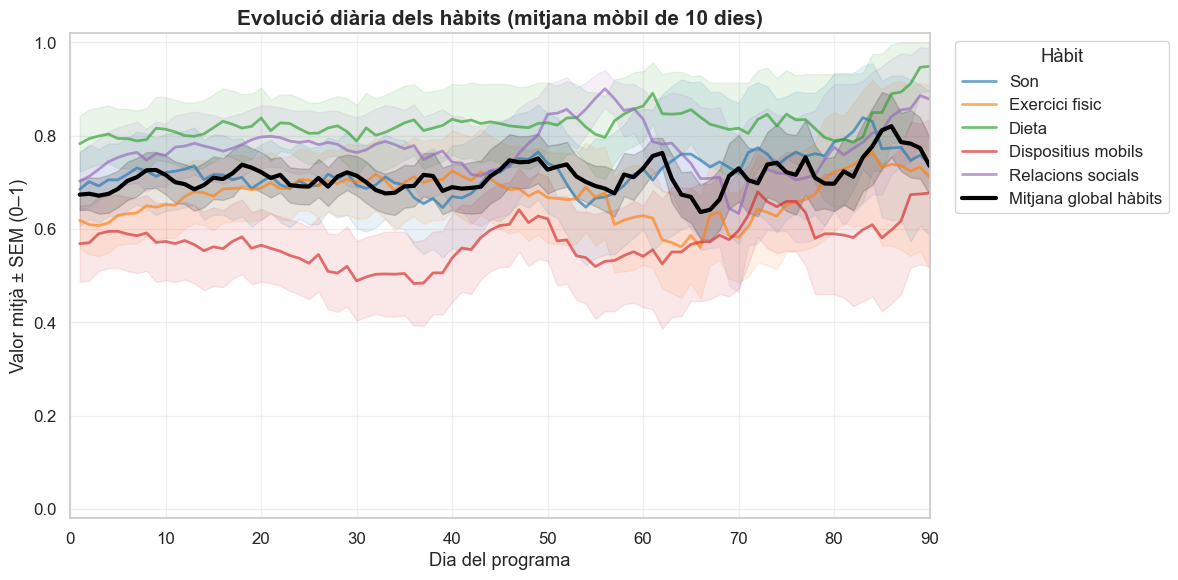

In [129]:
predictoras = ['son','exercici_fisic','dieta','dispositius_mobils','relacions_socials']

# asegurar tipos y orden
df = df.copy()
df['dia_intervencion'] = pd.to_numeric(df['dia_intervencion'], errors='coerce')
for h in predictoras:
    df[h] = pd.to_numeric(df[h], errors='coerce')
df = df.sort_values('dia_intervencion')

# ---- stats por hábito y día (USANDO .agg PARA EVITAR EL KEYERROR) ----

WIN=10

hab_stats = {}
for h in predictoras:
    s = (
        df.groupby('dia_intervencion')[h]
          .agg(mean='mean', n='count', std='std')      # columnas bien nombradas
          .assign(sem=lambda x: x['std'] / np.sqrt(x['n']))
          .reset_index()
          .sort_values('dia_intervencion')
    )
    # suavizado 5 días
    s['mean_smooth'] = s['mean'].rolling(window=WIN, min_periods=1, center=True).mean()
    s['sem_smooth']  = s['sem'].rolling(window=WIN,  min_periods=1, center=True).mean()
    hab_stats[h] = s

# ---- media global diaria (promedio de los 5 hábitos por fila, luego por día) ----
df['habitos_media'] = df[predictoras].mean(axis=1)
global_stats = (
    df.groupby('dia_intervencion')['habitos_media']
      .agg(mean='mean', n='count', std='std')
      .assign(sem=lambda x: x['std'] / np.sqrt(x['n']))
      .reset_index()
      .sort_values('dia_intervencion')
)
global_stats['mean_smooth'] = global_stats['mean'].rolling(window=5, min_periods=1, center=True).mean()
global_stats['sem_smooth']  = global_stats['sem'].rolling(window=5,  min_periods=1, center=True).mean()

# ---- plot ----
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(12, 6))
palette = sns.color_palette("tab10", len(predictoras))

# líneas de cada hábito (traslúcidas) + banda ±SEM
for (h, color) in zip(predictoras, palette):
    s = hab_stats[h]
    x, y, e = s['dia_intervencion'].to_numpy(), s['mean_smooth'].to_numpy(), s['sem_smooth'].to_numpy()
    plt.plot(x, y, color=color, linewidth=2, alpha=0.65, label=h.replace('_',' ').capitalize())
    plt.fill_between(x, y - e, y + e, color=color, alpha=0.10)

# línea negra global + banda ±SEM
xg, yg, eg = global_stats['dia_intervencion'], global_stats['mean_smooth'], global_stats['sem_smooth']
plt.plot(xg, yg, color='black', linewidth=3, label='Mitjana global hàbits')
plt.fill_between(xg, yg - eg, yg + eg, color='black', alpha=0.15)

plt.title(f"Evolució diària dels hàbits (mitjana mòbil de {WIN} dies)", fontsize=15, weight='bold')
plt.xlabel("Dia del programa")
plt.ylabel("Valor mitjà ± SEM (0–1)")
plt.ylim(-0.02, 1.02)
plt.xlim(0,90)
plt.grid(alpha=0.3)
plt.legend(title="Hàbit", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [136]:
import statsmodels.formula.api as smf

benestar = ['satisfaccio', 'exitacio', 'poder']
resultados_dia = {}

for b in benestar:
    print("\n" + "="*70)
    print(f"📈 Modelo de cambio temporal para: {b.upper()}")
    
    formula = f"{b} ~ dia_intervencion"
    modelo = smf.mixedlm(formula, data=df, groups=df["id"])
    
    res = modelo.fit(reml=False, method="nm", maxiter=1000, disp=False)
    resultados_dia[b] = res
    print(res.summary())


📈 Modelo de cambio temporal para: SATISFACCIO
           Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: satisfaccio
No. Observations:   1269    Method:             ML         
No. Groups:         31      Scale:              4.5480     
Min. group size:    30      Log-Likelihood:     -2813.3296 
Max. group size:    69      Converged:          Yes        
Mean group size:    40.9                                   
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         7.148    0.333 21.472 0.000  6.496  7.801
dia_intervencion -0.011    0.003 -4.198 0.000 -0.017 -0.006
Group Var         3.076    0.385                           


📈 Modelo de cambio temporal para: EXITACIO
          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: exitacio  
No. Observations:   1269    Meth

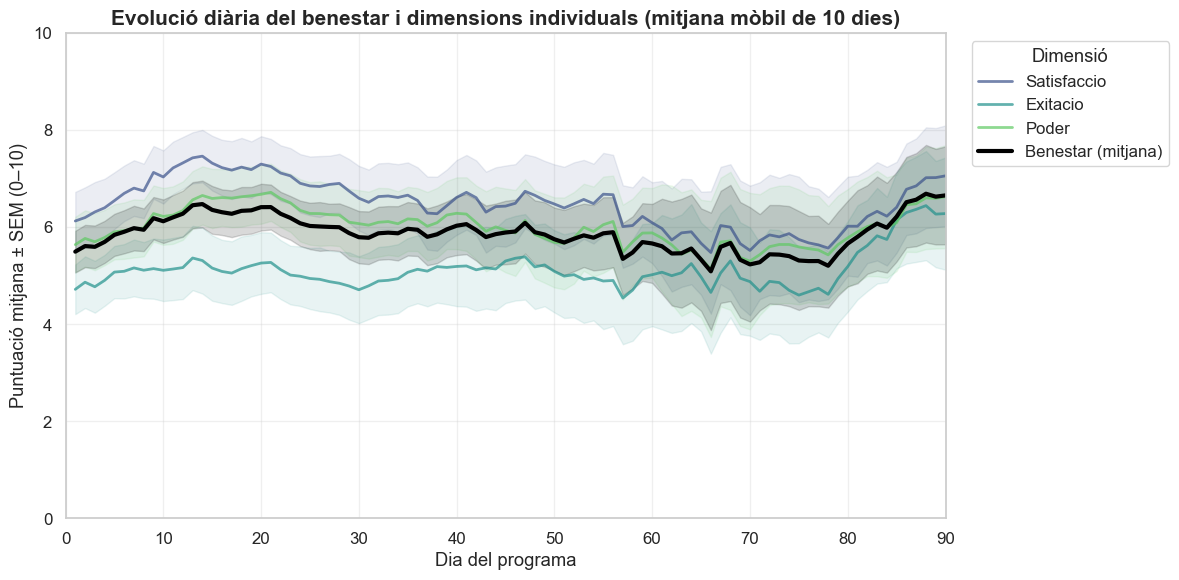

In [135]:
# --- Configuración ---
WIN = 10
bienestar_cols = ['satisfaccio', 'exitacio', 'poder']  # tres ejes del bienestar

# Copiamos y aseguramos tipos
dfb = df.copy()
dfb['dia_intervencion'] = pd.to_numeric(dfb['dia_intervencion'], errors='coerce')
for c in bienestar_cols:
    dfb[c] = pd.to_numeric(dfb[c], errors='coerce')

# Calculamos la media global (benestar)
dfb['benestar'] = dfb[bienestar_cols].mean(axis=1)

# --- Estadísticos por variable y día ---
bien_stats = {}
for c in bienestar_cols:
    s = (
        dfb.groupby('dia_intervencion')[c]
           .agg(mean='mean', n='count', std='std')
           .assign(sem=lambda x: x['std'] / np.sqrt(x['n']))
           .reset_index()
           .sort_values('dia_intervencion')
    )
    s['mean_smooth'] = s['mean'].rolling(window=WIN, min_periods=1, center=True).mean()
    s['sem_smooth']  = s['sem'].rolling(window=WIN,  min_periods=1, center=True).mean()
    bien_stats[c] = s

# --- Media global diaria de bienestar ---
ben_stats = (
    dfb.groupby('dia_intervencion')['benestar']
       .agg(mean='mean', n='count', std='std')
       .assign(sem=lambda x: x['std'] / np.sqrt(x['n']))
       .reset_index()
       .sort_values('dia_intervencion')
)
ben_stats['mean_smooth'] = ben_stats['mean'].rolling(window=WIN, min_periods=1, center=True).mean()
ben_stats['sem_smooth']  = ben_stats['sem'].rolling(window=WIN,  min_periods=1, center=True).mean()

# --- Plot ---
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(12, 6))

palette = sns.color_palette("viridis", len(bienestar_cols))

for (c, color) in zip(bienestar_cols, palette):
    s = bien_stats[c]
    x, y, e = s['dia_intervencion'], s['mean_smooth'], s['sem_smooth']
    plt.plot(x, y, color=color, linewidth=2, alpha=0.7, label=c.capitalize())
    plt.fill_between(x, y - e, y + e, color=color, alpha=0.1)

# Línea negra de benestar global
xg, yg, eg = ben_stats['dia_intervencion'], ben_stats['mean_smooth'], ben_stats['sem_smooth']
plt.plot(xg, yg, color='black', linewidth=3, label='Benestar (mitjana)')
plt.fill_between(xg, yg - eg, yg + eg, color='black', alpha=0.15)

# --- Estética ---
plt.title(f"Evolució diària del benestar i dimensions individuals (mitjana mòbil de {WIN} dies)", 
          fontsize=15, weight='bold')
plt.xlabel("Dia del programa")
plt.ylabel("Puntuació mitjana ± SEM (0–10)")
plt.xlim(0, 90)
plt.ylim(0, 10)
plt.grid(alpha=0.3)
plt.legend(title="Dimensió", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [14]:
# import bambi as bmb

# model = bmb.Model(
#     "satisfaccio ~ son+ exercici_fisic + dieta + dispositius_mobils + relacions_socials + (1|id)",
#     df, family="gaussian"
# )
# idata = model.fit(draws=2000, chains=4, target_accept=0.9)
# model.summary()

In [ ]:
%%capture --no-stderr

#Modelo multivariante jerárquico (PyMC): random intercepts correlacionados + residuos correlacionados

import pymc as pm
from tqdm import tqdm
import arviz as az

# Predictores (escala 0–1); estandarizamos para estabilidad numérica
Xcols = ['son', 'exercici_fisic', 'dieta', 'dispositius_mobils', 'relacions_socials']

X = df[Xcols].astype(float)
X = (X - X.mean()) / X.std(ddof=0)
X = X.to_numpy()  # (N, P)
P = X.shape[1]

# Resultado multivariante: ordenamos columnas en vec Y = [satisfaccion, calma, poder]
Ycols = ['satisfaccio','calma','poder']
Y = df[Ycols].astype(float).to_numpy()  # (N, 3)
N, K = Y.shape  # K=3

# Índices de sujeto
ids = pd.Categorical(df['id'])
J = len(ids.categories)
subj_idx = ids.codes  # (N,)

with pm.Model() as model:
    # ----- Priors de efectos fijos -----
    # Interceptos para cada outcome
    alpha = pm.Normal("alpha", 0.0, 1.0, shape=K)  # (3,)
    # Betas por outcome y predictor (matriz K x P)
    beta = pm.Normal("beta", 0.0, 1.0, shape=(K, P))  # (3, P)

    # ----- Random intercepts por sujeto (correlacionados entre outcomes) -----
    # Matriz de covarianza a nivel sujeto: Sigma_u (KxK), via LKJ
    sd_u = pm.HalfNormal("sd_u", 1.0, shape=K)
    chol_u, corr_u, sigma_u = pm.LKJCholeskyCov(
        "Sigma_u", n=K, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0), compute_corr=True
    )
    # Interceptos aleatorios por sujeto ~ MVN(0, Sigma_u)
    z_u = pm.Normal("z_u", 0.0, 1.0, shape=(J, K))
    u = pm.Deterministic("u", z_u @ chol_u.T)  # (J, K)

    # ----- Residuos a nivel observación (correlacionados entre outcomes) -----
    sd_e = pm.HalfNormal("sd_e", 1.0, shape=K)
    chol_e, corr_e, sigma_e = pm.LKJCholeskyCov(
        "Sigma_e", n=K, eta=2.0, sd_dist=pm.HalfNormal.dist(1.0), compute_corr=True
    )

    # ----- Media lineal para cada observación y outcome -----
    # mu[i, k] = alpha[k] + X[i,:] @ beta[k,:] + u[subj_idx[i], k]
    mu = alpha + (X @ beta.T) + u[subj_idx]  # (N, K)

    # ----- Verosimilitud multivariante -----
    Y_obs = pm.MvNormal("Y_obs", mu=mu, chol=chol_e, observed=Y)

    idata = pm.sample(2000, tune=2000, target_accept=0.9, chains=4, random_seed=42, progressbar=True)
    az.summary(idata, var_names=["alpha","beta","sd_u","sd_e","Sigma_u","Sigma_e"])


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sd_u, Sigma_u, z_u, sd_e, Sigma_e]
